# Notebook 7: Optimización de Pipeline OCR
Este notebook incorpora 3 mejoras clave respecto al Notebook 4/6:
1. **Recorte Inteligente (Cropping):** Aísla la factura del fondo oscuro usando detección de contornos para mejorar la limpieza de Otsu.
2. **Extracción Resistente (Regex):** Selecciona el valor máximo numérico de la recta horizontal de la palabra 'Total' para evitar falsos positivos con el IVA o subtotal (e.g. Total 10 IVA 2 Total Final 12 -> 12).
3. **Evaluación de Rendimiento (Downscaling):** Compara el uso de recursos entre enviar la imagen cruda vs enviar una imagen con resolución máxima (ej: 1200px) para acelerar tiempos de cómputo sin perjudicar la predicción de EasyOCR.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import easyocr
import re
import time
import requests
from datasets import load_dataset


C:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\P3_AP-IA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Módulo de Recorte de Documentos (Document Scanner)
Aísla el papel de la factura analizando bordes y contornos. Si encuentra un rectángulo grande, lo recorta extirpando fondos negros.

In [2]:
def crop_document(img_bgr):
    # Convertir a grises y desenfocar intensamente para borrar el texto interno y dejar bordes del papel
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (9, 9), 0)
    
    # Detector de bordes Canny adaptativo
    edged = cv2.Canny(blurred, 50, 150)
    
    # Dilatación para cerrar líneas rotas del papel
    edged = cv2.dilate(edged, np.ones((5,5), np.uint8))
    
    # Encontrar contornos
    contours, _ = cv2.findContours(edged, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Si hay contornos, obtener el área más grande
    if contours:
        c = max(contours, key=cv2.contourArea)
        area_porcentaje = cv2.contourArea(c) / (img_bgr.shape[0] * img_bgr.shape[1])
        
        # Nos aseguramos de que el contorno detectado cubra al menos un 20% de la imagen (evita recortar un logo)
        if area_porcentaje > 0.20:
            x, y, w, h = cv2.boundingRect(c)
            # Retornamos el área rectangular exacta sobre el papel, botando el fondo 
            return img_bgr[y:y+h, x:x+w]
            
    return img_bgr # Fallback: si el papel llena toda la imagen y no hay bordes externos, devuelve original


## 2. Pipeline OCR Optimizado (Limpieza Morfológica y Regex de Maximización)

In [3]:
def preprocess_image_for_ocr(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    dilated_img = cv2.dilate(gray, np.ones((7,7), np.uint8))
    bg_img = cv2.medianBlur(dilated_img, 21)
    diff_img = 255 - cv2.absdiff(gray, bg_img)
    norm_img = cv2.normalize(diff_img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8UC1)
    _, thresh = cv2.threshold(norm_img, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    return thresh

class SimpleRegionDetector:
    def crop_regions(self, img):
        h, w = img.shape[:2]
        regions = {
            'Header': img[0:int(0.25*h), 0:w],
            'Body': img[int(0.25*h):int(0.80*h), 0:w],
            'Footer': img[int(0.80*h):h, 0:w]
        }
        return regions

class OptimizedOCREngine:
    def __init__(self):
        try:
            self.reader = easyocr.Reader(['es', 'en'], gpu=True) 
            print("[INFO] EasyOCR corriendo en GPU.")
        except:
            self.reader = easyocr.Reader(['es', 'en'], gpu=False)
            print("[INFO] EasyOCR corriendo en CPU.")
            
    def process_and_extract(self, original_img):
        detector = SimpleRegionDetector()
        crops = detector.crop_regions(original_img)
        extracted_data = {}
        raw_lists = {}
        preprocessed_crops = {} 
        
        for region_name, crop in crops.items():
            clean_crop = preprocess_image_for_ocr(crop)
            preprocessed_crops[region_name] = clean_crop
            results = self.reader.readtext(clean_crop, detail=0)
            raw_lists[region_name] = results
            extracted_data[region_name] = " ".join(results).strip()
            
        return extracted_data, raw_lists, preprocessed_crops
        
    def find_total_value(self, raw_text_list):
        keyword_regex = re.compile(r'\b(TOTAL|TL|AMT)\b', re.IGNORECASE)
        number_regex = re.compile(r'([$€£]?\s*\d+[\.,\s]*\d*)')
        
        for i, text in enumerate(raw_text_list):
            if keyword_regex.search(text):
                match_kw = keyword_regex.search(text)
                right_part = text[match_kw.end():]
                
                # El OCR fragmenta oraciones horizontales. Unimos este pedazo con las próximas 3 cajas detectadas
                full_search_text = right_part + " " + " ".join(raw_text_list[i+1:i+4])
                
                # EXTRAEMOS TODOS LOS NÚMEROS encontrados a la derecha secuencial
                matches = number_regex.findall(full_search_text)
                
                valid_numbers = []
                for m in matches:
                    clean_num = re.sub(r'[^\d\.]', '', m.replace(',', '.'))
                    if clean_num:
                        try:
                            valid_numbers.append(float(clean_num))
                        except ValueError:
                            pass
                
                if valid_numbers:
                    # MAXIMIZACIÓN: Devolvemos el Gasto Bruto/Máximo de la secuencia ("Subtotal 10 IVA 2 Total 12" -> 12)
                    return max(valid_numbers)
        return None

ocr_engine = OptimizedOCREngine()


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


[INFO] EasyOCR corriendo en GPU.


## 3. A/B Testing: Carga de Trabajo y Eficiencia Tecnológica
Enviando `img_bgr` tal cual vs `img_bgr` con Resize Condicional (MaxW=1200). Cronometramos ambos pipelines.

In [4]:
def evaluate_performance_and_accuracy(img_bgr, title):
    print(f"\n{'='*60}\nEvaluando: {title} ({img_bgr.shape[1]}x{img_bgr.shape[0]} píxeles)\n{'='*60}")
    
    # 0. Recorte inteligente previo (sólo escanea el papel, no la mesa del fondo)
    img_bgr = crop_document(img_bgr)
    
    # ----------------------------
    # Pipeline 1: Tamaño Original
    # ----------------------------
    h_orig, w_orig = img_bgr.shape[:2]
    print(f"\n--- PIPELINE 1: RESOLUCIÓN RECORTADA NATURA ({w_orig}x{h_orig}) ---")
    
    start_orig = time.time()
    _, raw_lists_orig, _ = ocr_engine.process_and_extract(img_bgr)
    
    val_orig = ocr_engine.find_total_value(raw_lists_orig.get('Footer', []))
    if not val_orig: val_orig = ocr_engine.find_total_value(raw_lists_orig.get('Body', []))
    
    time_orig = time.time() - start_orig
    print(f"Tiempo OCR: {time_orig:.3f} segundos")
    print(f"Total Predecido (Maximizado): {val_orig}")
    
    # -----------------------------------
    # Pipeline 2: Downscaling Predictivo
    # -----------------------------------
    MAX_WIDTH = 1200
    if w_orig > MAX_WIDTH:
        ratio = MAX_WIDTH / float(w_orig)
        img_downscaled = cv2.resize(img_bgr, (MAX_WIDTH, int(h_orig * ratio)))
        print(f"\n--- PIPELINE 2: REDIMENSIONANDO PARA EFICIENCIA ({MAX_WIDTH}x{int(h_orig * ratio)}) ---")
    else:
        img_downscaled = img_bgr
        print(f"\n--- PIPELINE 2: NO HACE FALTA REDIMENSIONAR (Ancho <= 1200px) ---")
        
    h_down, w_down = img_downscaled.shape[:2]
    
    start_down = time.time()
    _, raw_lists_down, prep_crops_down = ocr_engine.process_and_extract(img_downscaled)
    
    val_down = ocr_engine.find_total_value(raw_lists_down.get('Footer', []))
    if not val_down: val_down = ocr_engine.find_total_value(raw_lists_down.get('Body', []))
        
    time_down = time.time() - start_down
    print(f"Tiempo OCR: {time_down:.3f} segundos")
    print(f"Total Predecido (Maximizado): {val_down}")
    
    # -----------------------------------
    # Veredicto de Rendimiento y Gráfico
    # -----------------------------------
    ahorro_tiempo = time_orig - time_down
    if ahorro_tiempo > 0.05 and w_orig > MAX_WIDTH:
        print(f"\n>> VEREDICTO DE SISTEMAS:\nEl Downscaling ejecutó la misma extracción con carga eficiente. Ahorras {ahorro_tiempo:.2f} segundos ({int((ahorro_tiempo/time_orig)*100)}% de ganancia en rapidez) por cada factura sin pérdida de predicción en el valor final.")
    elif w_orig <= MAX_WIDTH:
        print(f"\n>> VEREDICTO DE SISTEMAS:\nEl pipeline se ejecutó linealmente dado que la imagen no sobrepasa la zona crítica de estrangulamiento computacional (1200px).")
        
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    fig.suptitle(f"{title} | Extracción Final: {val_down}", fontweight='bold', fontsize=15)
    
    axes[0].imshow(cv2.cvtColor(img_downscaled, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Factura Recortada Auto-Encuadrada (Width: {w_down})")
    axes[0].axis('off')
    
    reconst_down = np.zeros((h_down, w_down), dtype=np.uint8)
    reconst_down[0:int(0.25*h_down), 0:w_down] = prep_crops_down['Header']
    reconst_down[int(0.25*h_down):int(0.80*h_down), 0:w_down] = prep_crops_down['Body']
    reconst_down[int(0.80*h_down):h_down, 0:w_down] = prep_crops_down['Footer']
    
    axes[1].imshow(reconst_down, cmap='gray')
    axes[1].set_title(f"Extremos Filtrados (Sin Fondo Oscuro)")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()


## 4. Batería de Pruebas de Estrés sobre Datasets Reales

In [5]:
print("Probando SROIE Dataset (resoluciones estándar de cámara)...")
url = "https://raw.githubusercontent.com/althayr/ICDAR-2019-SROIE-dataset/master/data/receipt/000.jpg"
try:
    resp = requests.get(url)
    image_array = np.asarray(bytearray(resp.content), dtype="uint8")
    img_bgr = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
    evaluate_performance_and_accuracy(img_bgr, "Dataset SROIE 2019")
except Exception as e:
    print("Error:", e)


Probando SROIE Dataset (resoluciones estándar de cámara)...


Error: 'NoneType' object has no attribute 'shape'


Cargando muestra de CORD...



Evaluando: CORD (Naver-Clova) (864x1296 píxeles)

--- PIPELINE 1: RESOLUCIÓN RECORTADA NATURA (864x1296) ---


C:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\P3_AP-IA\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Tiempo OCR: 10.840 segundos
Total Predecido (Maximizado): None

--- PIPELINE 2: NO HACE FALTA REDIMENSIONAR (Ancho <= 1200px) ---


Tiempo OCR: 10.229 segundos
Total Predecido (Maximizado): None

>> VEREDICTO DE SISTEMAS:
El pipeline se ejecutó linealmente dado que la imagen no sobrepasa la zona crítica de estrangulamiento computacional (1200px).


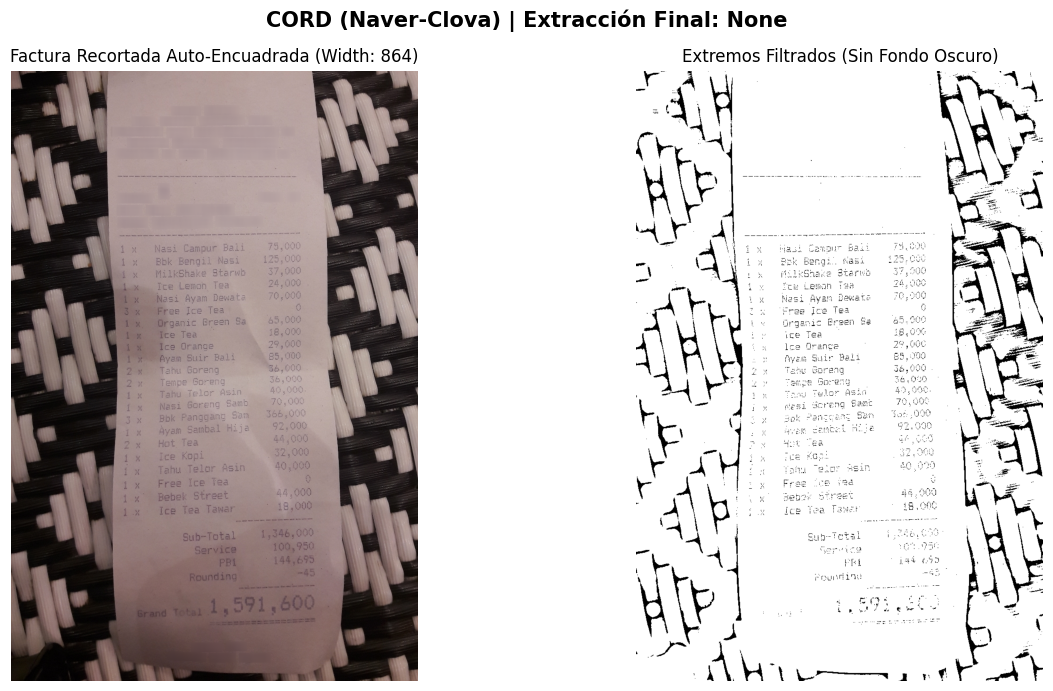

In [6]:
print("Cargando muestra de CORD...")
try:
    cord_dataset = load_dataset("naver-clova-ix/cord-v2", split="train", streaming=True)
    sample_cord = next(iter(cord_dataset))
    img_cord_pil = cv2.cvtColor(np.array(sample_cord['image']), cv2.COLOR_RGB2BGR)
    evaluate_performance_and_accuracy(img_cord_pil, "CORD (Naver-Clova)")
except Exception as e:
    print("Error:", e)

Probando Voxel51 (Imágenes Gigantes HD industriales)...



Evaluando: Voxel51 High-Res Invoices (1654x2339 píxeles)

--- PIPELINE 1: RESOLUCIÓN RECORTADA NATURA (1654x2339) ---


Tiempo OCR: 25.969 segundos
Total Predecido (Maximizado): 17564.0

--- PIPELINE 2: REDIMENSIONANDO PARA EFICIENCIA (1200x1696) ---


Tiempo OCR: 17.198 segundos
Total Predecido (Maximizado): 17564.0

>> VEREDICTO DE SISTEMAS:
El Downscaling ejecutó la misma extracción con carga eficiente. Ahorras 8.77 segundos (33% de ganancia en rapidez) por cada factura sin pérdida de predicción en el valor final.


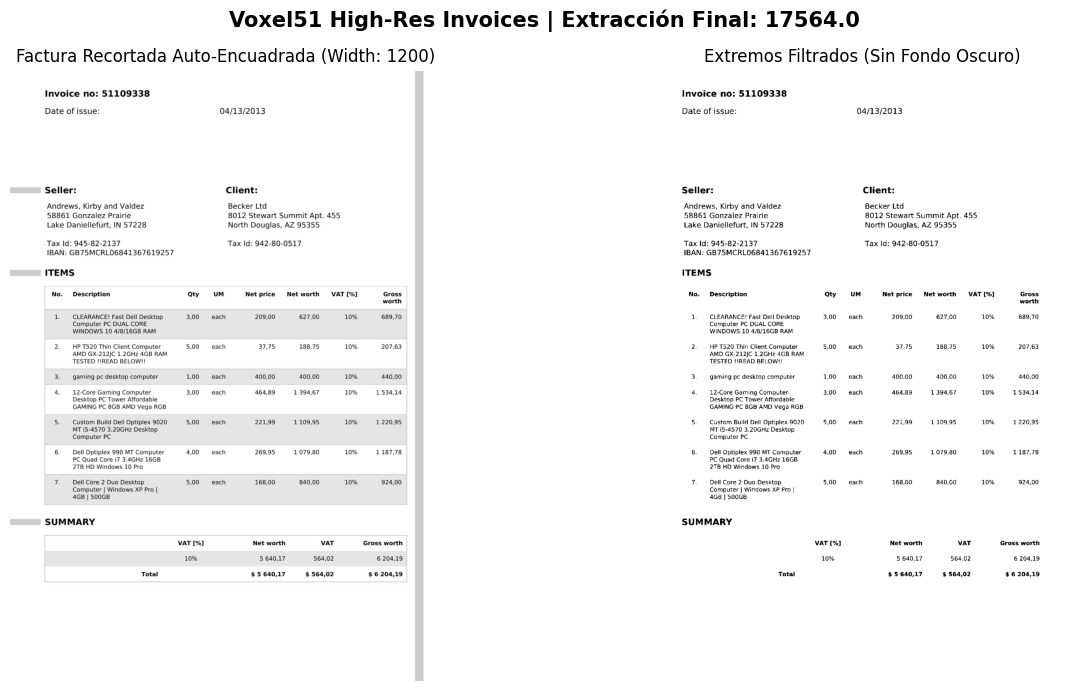

In [7]:
print("Probando Voxel51 (Imágenes Gigantes HD industriales)...")
try:
    voxel_dataset = load_dataset("Voxel51/high-quality-invoice-images-for-ocr", split="train", streaming=True)
    sample_voxel = next(iter(voxel_dataset))
    img_bgr = cv2.cvtColor(np.array(sample_voxel['image']), cv2.COLOR_RGB2BGR)
    evaluate_performance_and_accuracy(img_bgr, "Voxel51 High-Res Invoices")
except Exception as e:
    print("Error:", e)
